# Plotting notebook for background


In [2]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep
from helpers import merge_bkg, merge_cutflows
import shutil
from helpers import *
# import hep

In [2]:
# Add samples to output file
# vr = "32c"
# vd = "32d"
# sam = ["bkg_32d_4Mu500_1p2", "bkg_32d_4Mu800_1p2", "bkg_32d_4Mu1000_1p2"]

# outini = coffea.util.load(f"outputs/bkg_{vr}.coffea")
# for s in sam:
#     print(f"outputs/{sam}.coffea")
#     outp  = coffea.util.load(f"outputs/{sam}.coffea")
#     outini |= outp

# coffea.util.save(output, f"outputs/bkg_{vd}.coffea")
# output = coffea.util.load(f"outputs/bkg_{vd}.coffea")
# for sam in output:
#     print(sam)

In [3]:
# vr = "32c"
# vd = "32d"
# outini = coffea.util.load(f"outputs/bkg_{vr}.coffea")
# print(f"openning: outputs/bkg_{vr}.coffea")
# sam = ["bkg_32d_4Mu500_1p2", "bkg_32d_4Mu800_1p2", "bkg_32d_4Mu1000_1p2"]
# for s in sam:
#     print(f"openning: outputs/{s}.coffea")
#     outp = coffea.util.load(f"outputs/{s}.coffea")

#     # repeated = outini.keys() & outp.keys()
#     # if repeated:
#     #     print(f"{s}: replacing {len(repeated)} keys")
#     #     print(sorted(repeated))

#     outini |= outp
# coffea.util.save(outini, f"outputs/bkg_{vd}.coffea")
# output = coffea.util.load(f"outputs/bkg_{vd}.coffea")

In [4]:
### # sample = list(outall.keys())[0]
# print(type(outall[sample]))
# print(outall[sample].keys())
# print(outall[sample]["hists"].keys())
# for k in outall:
    # print(k)
    # print(k["hists"].keys())
    # outp = coffea.util.load(f"outputs/bkg_{vr}_{sam}.coffea")
# output = outp 

In [5]:
# for k in output:
#     print(k)

In [6]:
# output = coffea.util.load(f"outputs/bkg_32d_4Mu1000_1p2.coffea")
# for k in output:
#     print(k)

In [4]:
# configs for 38 Carefull with all this definitions: All work should be done here

save = 0 #saving plots? 
vr = "38"

process = [
    # "fmu1", 
    # "fmu2", 
    # "fmu3",
    # "fmu4", 
    # "fmu5", 
    # "fmu6",
    # "fmu7",
    "fmu8",
    "fmu9",
    # "fmu0",
    # "fmui",
    # "fmux",
    "ttj",
    "dyj1",
    "dyj2",
    # "qcd1", 
    # "qcd2",  
    # "qcd3", 
    # "qcd4",
    # "qcd5",
    # "qcd6", 
    # "qcd7", 
    # "qcd8",
    # "qcd9",
    # "qcd0", 
    "qcdi",
    "qcdx",
]

outall = {}
for p in process:
    outp = coffea.util.load(f"outputs/bkg_{vr}_{p}.coffea")
    outall |= outp

coffea.util.save(outall, f"outputs/bkg_{vr}.coffea")
# print(f"output file bkg_{vr}.coffea saved")

bkgttj = ["TTJets"]
bkgdyj = ["DYJetsToMuMu_M10to50", "DYJetsToMuMu_M50",]
bkgqcd = ["QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80", "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300", "QCD_Pt300To470", "QCD_Pt470To600",
          "QCD_Pt600To800", "QCD_Pt800To1000", "QCD_Pt1000"]

channels = [
    "bkg_2mulj_iso_disp_dphi_ljmdiff1"
    # "bkg_2mulj",
    # "bkg_2mulj_iso",
    # "bkg_2mulj_iso_disp",
    # "bkg_2mulj_iso_disp_dphi",
    # "bkg_2mulj_iso_disp_dphi_ljmp10",
    # "bkg_2mulj_iso_disp_dphi_ljmp15",
    # "bkg_2mulj_iso_disp_dphi_ljmp20",
    # "bkg_2mulj_iso_disp_dphi_ljmp30",
    # "bkg_2mulj_iso_disp_dphi_ljmp10_mass150",
]

ch1 = channels[0]
# ch2 = channels[1]
# ch3 = channels[2]
# ch4 = channels[3]
# ch5 = channels[4]
# ch6 = channels[5]
# ch7 = channels[6]
# ch8 = channels[7]
# ch9 = channels[8]
# ch0 = channels[9]
# ch7 = channels[6]

# chan = [ch1, ch2, ch3, ch4, ch5, ch6, ch7, ch8, ch9]
chan = [ch1]

chaname = ["mlj1-mlj2 < 1"]
# chaname = ["2mulj", "Iso", "Disp", "dphi2", "ljmp10", "mjj150"]

sss = "4Mu_800GeV_1p2GeV_1p2mm"
signal = fmulxy8
all_signal = fmulxy8 +  fmulxy9
# all_signal = fmulxy2 + fmulxy3 + fmulxy5 + fmulxy6 + fmulxy8 + fmulxy9 + fmulxyi + fmulxyx
# all_signal = fmulxy1 + fmulxy2 + fmulxy3 + fmulxy4 + fmulxy5 + fmulxy6 + fmulxy7 + fmulxy8 +  fmulxy9 + fmulxy0 + fmulxyi + fmulxyx

output = coffea.util.load(f"outputs/bkg_{vr}.coffea")


# for k in output:
#     print(k)

# if save:
#     print("\n Saving output files\n")
# else:
#     print("\nNo output files will be saved\n")

# #use the correct label for leyend
# if "500" in labl:
#     print("working with Bound state mass")
#     labti = r"$B_s$ [GeV]"
#     print(f"legent title {labti}")
# elif "30" in labl:
#     print("working with Lxy")
#     labti = r"$L_{xy}$ [cm]"
#     print(f"legent title {labti}")
# elif "1p2" in labl:
#     print("Working with Dark photon mass")
#     labti = r"$m_zd$ [GeV]"
#     # labl = ["0p25", "1p2", "5p0"]
# else:
#     print("Stop mijo: check your labels definitions")
#     print(vamos-mijo)

# print(signal)

In [5]:
# Global variables
histoplot = ["lj_lj_invmass",]#, "lj_lj_absdphi", "lj_lj_absdR", "lj_lj_absdeta"]
colsig=["black", "darkviolet", "navy", "magenta", "darkorange", "darkblue"]

figh, figw = 12, 10

# Lepton jet masses:

['bkg_2mulj_iso_disp_dphi_ljmdiff1']


KeyError: "'bkg_2mulj_iso_disp_dphi_ljmdiff1' not in axis"

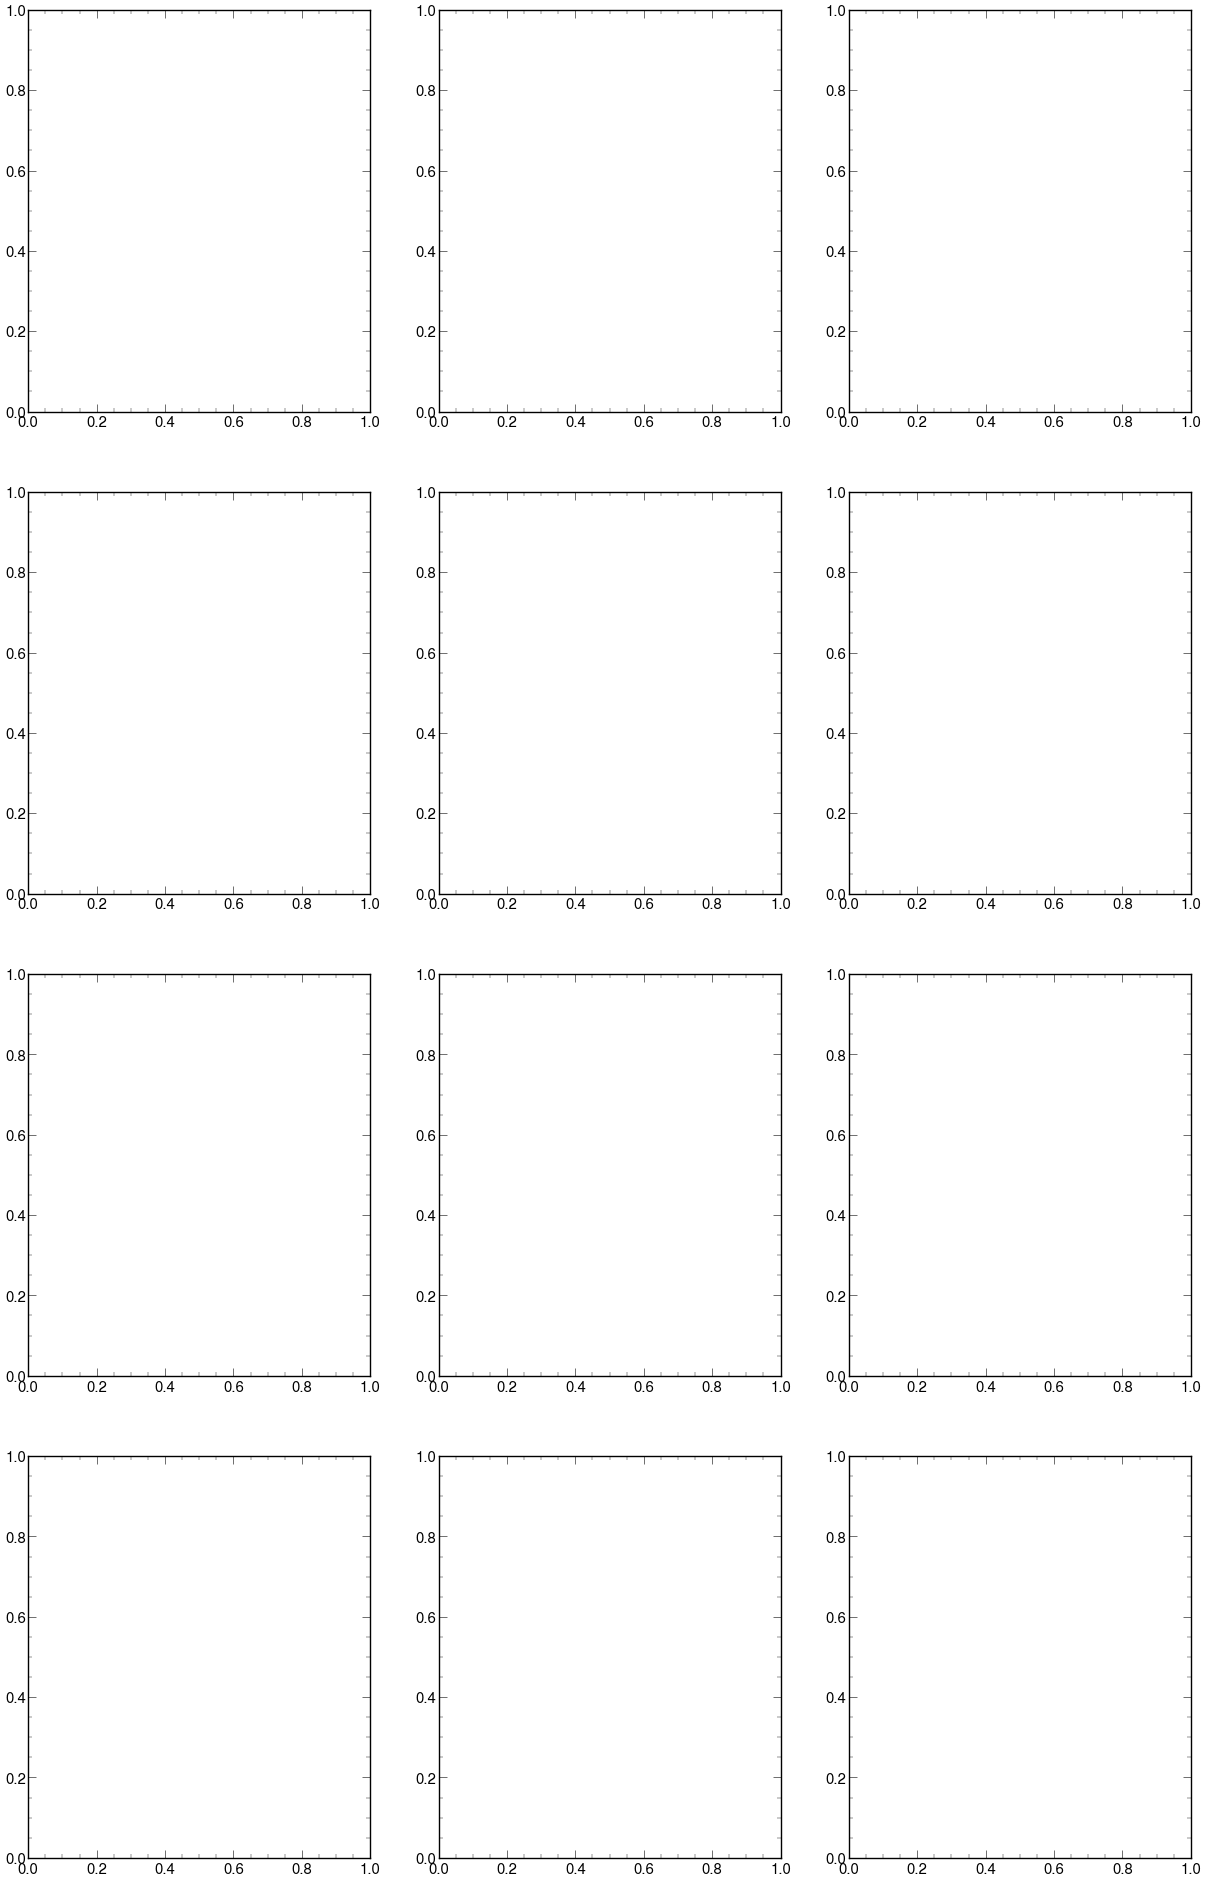

In [6]:
print(chan)
npy = 3
npx = 4
plt.subplots(npx, npy, figsize=(npy*figw, npx*figh))
parts = sss.split("_")

for ix, ch in enumerate(chan):
    
    plt.subplot(npx, npy, 1)
    utilities.plot(output[sss]["hists"]["lj0_mass"][ch, :], label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"{parts[1]}, {parts[2]}, 30 cm  \n Selection:", alignment="left", loc=0)
    
    plt.subplot(npx, npy, 2)
    utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"{parts[1]}, {parts[2]}, 30 cm  \n Selection:", alignment="left", loc=0)

    plt.subplot(npx, npy, 3)
    utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch, :], label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"{parts[1]}, {parts[2]}, 30 cm  \n Selection:", alignment="left", loc=0)
    if (save): plt.savefig(f"clean_plots/fin_bkg_ljmass_{vr}_signal.pdf", bbox_inches="tight", dpi=300)
    # print(f"clean_plots/fin_bkg_ljmass_{vr}_signal.pdf")
    
    ##### TTJets #####
    plt.subplot(npx, npy, 4)
    utilities.plot(merge_bkg(output, bkgttj, "lj0_mass", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"TTJets \n Selection:", alignment="left", loc=0)

    plt.subplot(npx, npy, 5)
    utilities.plot(merge_bkg(output, bkgttj, "lj1_mass", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"TTJets \n Selection:", alignment="left", loc=0)

    plt.subplot(npx, npy, 6)
    utilities.plot(merge_bkg(output, bkgttj, "lj01_massdiff", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"TTJets \n Selection:", alignment="left", loc=0)

    ### DYJets ########
    plt.subplot(npx, npy, 7)
    utilities.plot(merge_bkg(output, bkgdyj, "lj0_mass", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"DYJets \n Selection:", alignment="left", loc=0)

    plt.subplot(npx, npy, 8)
    utilities.plot(merge_bkg(output, bkgdyj, "lj1_mass", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"DYJets \n Selection:", alignment="left", loc=0)

    plt.subplot(npx, npy, 9)
    utilities.plot(merge_bkg(output, bkgdyj, "lj01_massdiff", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"DYJets \n Selection:", alignment="left", loc=0)

    ### QCD ########
    plt.subplot(npx, npy, 10)
    utilities.plot(merge_bkg(output, bkgqcd, "lj0_mass", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"QCD \n Selection:", alignment="left", loc=0)

    plt.subplot(npx, npy, 11)
    utilities.plot(merge_bkg(output, bkgqcd, "lj1_mass", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"QCD \n Selection:", alignment="left", loc=0)

    plt.subplot(npx, npy, 12)
    utilities.plot(merge_bkg(output, bkgqcd, "lj01_massdiff", ch), label = chaname[ix])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"QCD \n Selection:", alignment="left", loc=0)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variance

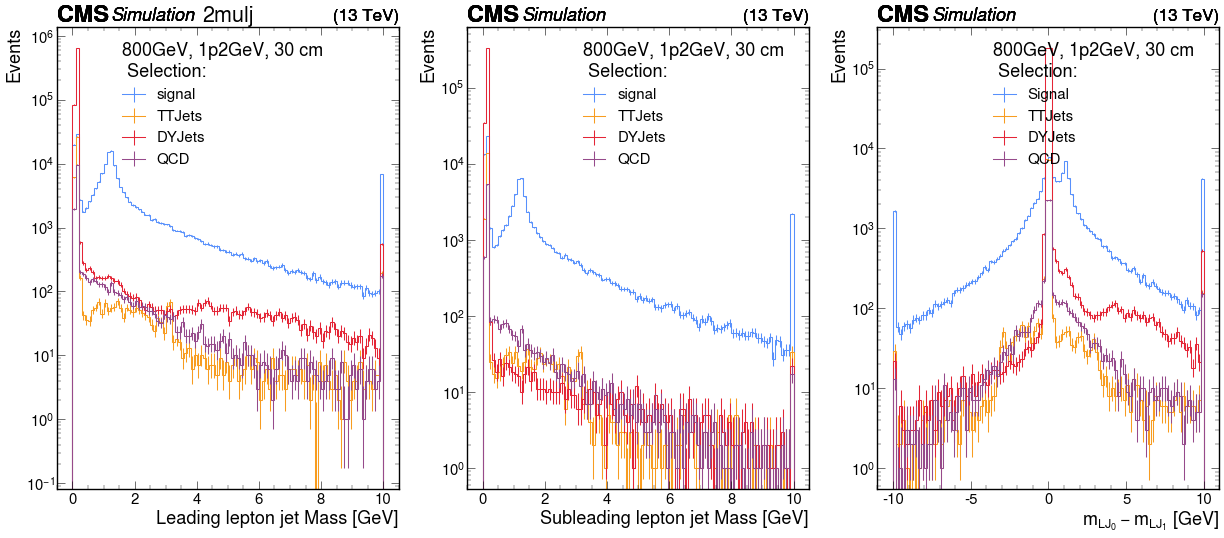

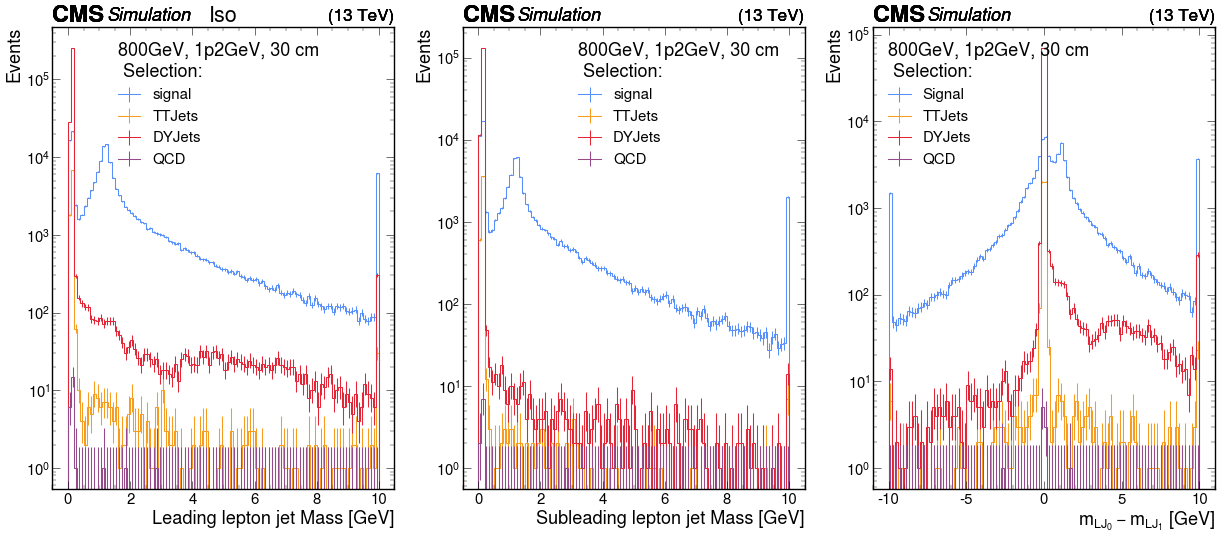

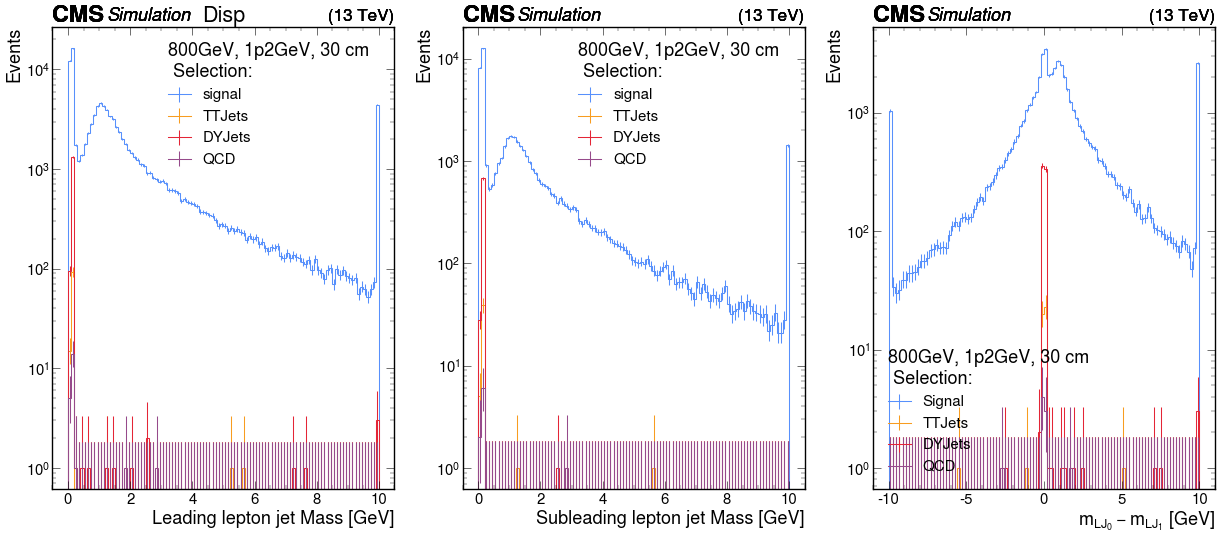

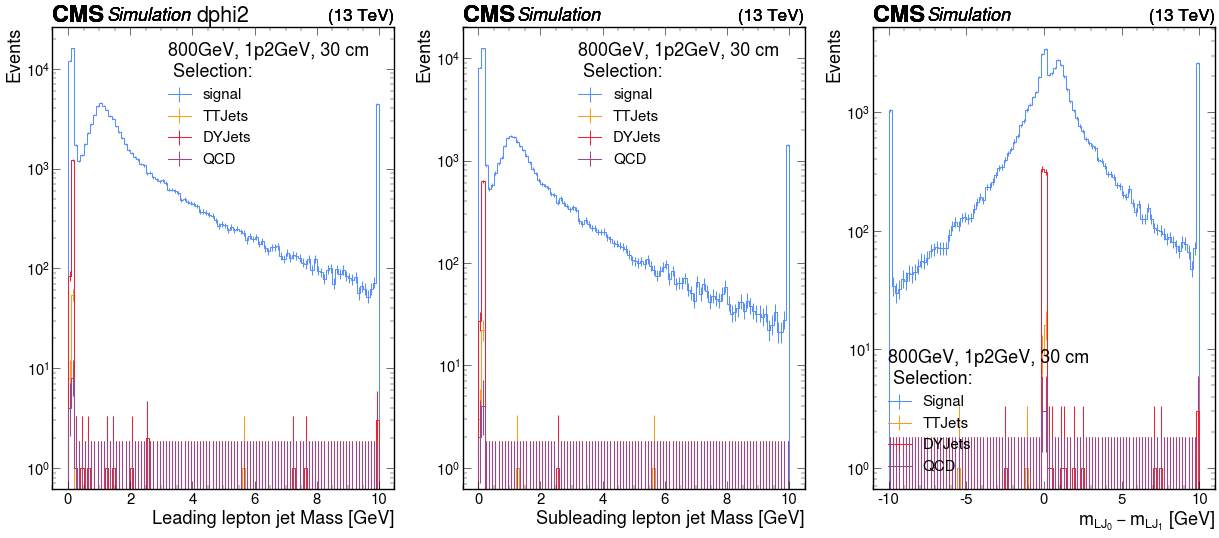

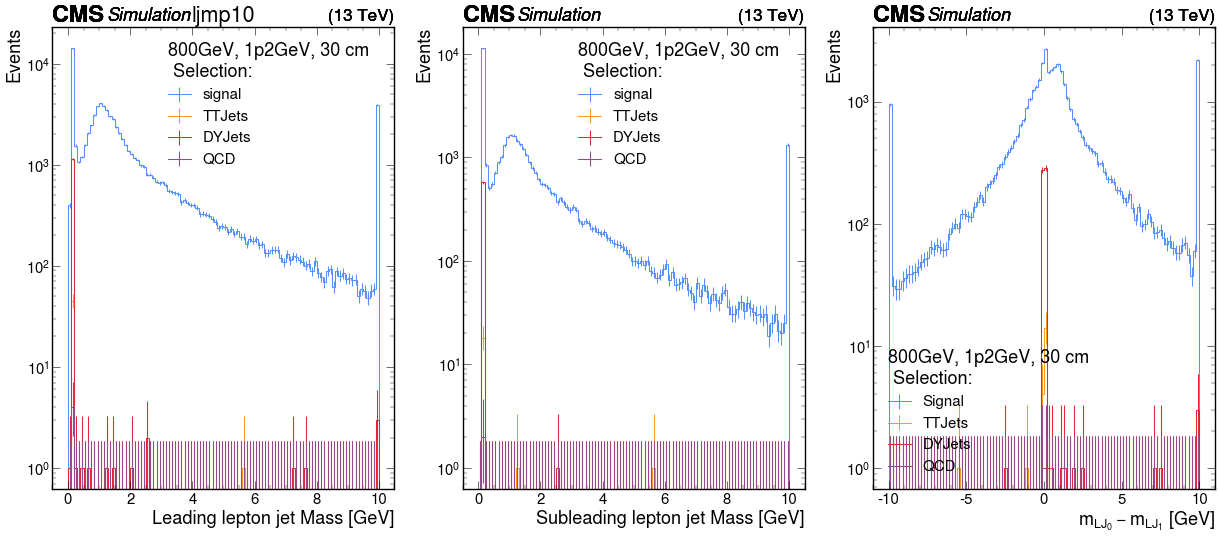

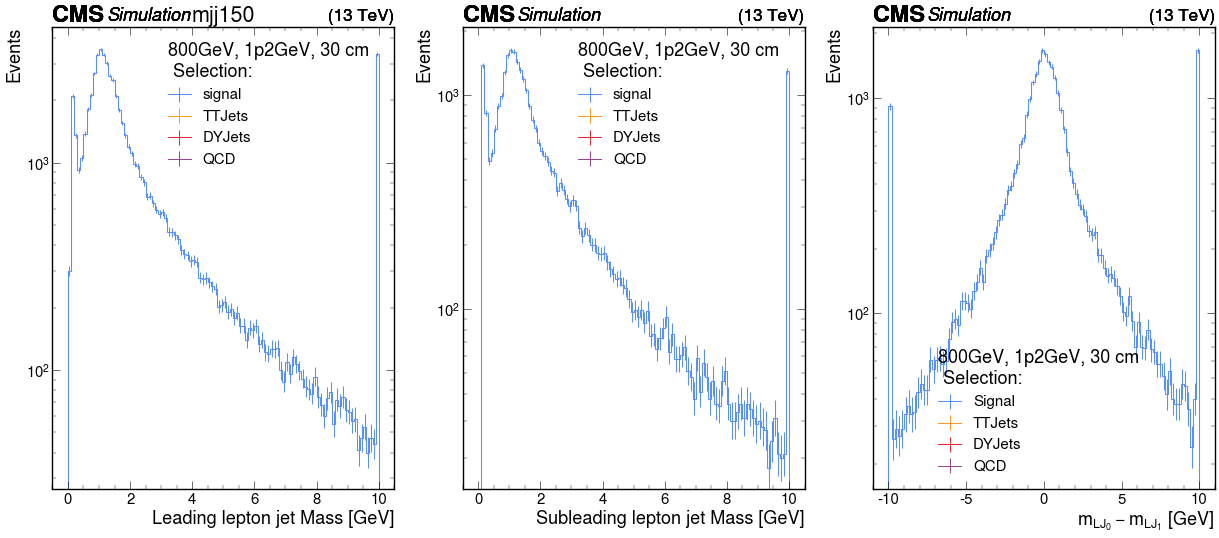

In [10]:
npx = 1
npy = 3
# plt.subplots(npx, npy, figsize=(npy*figw, npx*figh))
parts = sss.split("_")

for ix, ch in enumerate(chan):
    plt.subplots(npx, npy, figsize=(npy*figw, npx*figh))
    plt.subplot(npx, npy, 1)
    utilities.plot(output[sss]["hists"]["lj0_mass"][ch, :], label = "signal")
    utilities.plot(merge_bkg(output, bkgttj, "lj0_mass", ch), label = "TTJets")
    utilities.plot(merge_bkg(output, bkgdyj, "lj0_mass", ch), label = "DYJets")
    utilities.plot(merge_bkg(output, bkgqcd, "lj0_mass", ch), label = "QCD")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.title(chaname[ix])
    plt.legend(title=f"{parts[1]}, {parts[2]}, 30 cm  \n Selection:", alignment="left", loc=0)
    
    plt.subplot(npx, npy, 2)
    utilities.plot(output[sss]["hists"]["lj1_mass"][ch, :], label = "signal")
    utilities.plot(merge_bkg(output, bkgttj, "lj1_mass", ch), label = "TTJets")
    utilities.plot(merge_bkg(output, bkgdyj, "lj1_mass", ch), label = "DYJets")
    utilities.plot(merge_bkg(output, bkgqcd, "lj1_mass", ch), label = "QCD")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"{parts[1]}, {parts[2]}, 30 cm  \n Selection:", alignment="left", loc=0)

    plt.subplot(npx, npy, 3)
    utilities.plot(output[sss]["hists"]["lj01_massdiff"][ch, :], label = "Signal")
    utilities.plot(merge_bkg(output, bkgttj, "lj01_massdiff", ch), label = "TTJets")
    utilities.plot(merge_bkg(output, bkgdyj, "lj01_massdiff", ch), label = "DYJets")
    utilities.plot(merge_bkg(output, bkgqcd, "lj01_massdiff", ch), label = "QCD")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=f"{parts[1]}, {parts[2]}, 30 cm  \n Selection:", alignment="left", loc=0)
    if (save): plt.savefig(f"clean_plots/fin_bkg_ljmass_{vr}_signal.pdf", bbox_inches="tight", dpi=300)
    # print(f"clean_plots/fin_bkg_ljmass_{vr}_signal.pdf")

# Bin Content

In [11]:
ht = merge_bkg(output, bkgttj, "lj1_mass", "bkg_2mulj_iso_disp_dphi")
hd = merge_bkg(output, bkgdyj, "lj1_mass", "bkg_2mulj_iso_disp_dphi")
hq = merge_bkg(output, bkgqcd, "lj1_mass", "bkg_2mulj_iso_disp_dphi")
hs =           output[sss]["hists"]["lj1_mass"][ch, :]
# print(ht.axes[0].size)
# print(len(ht.values()))
# print(ht.axes[0].edges)

In [12]:
x= 5
print(f"ttj: {ht.values()[:x]}")
print(f"dyj: {hd.values()[:x]}")
print(f"qcd: {hq.values()[:x]}")
print(f"sig: {hs.values()[:x]}")

ttj: [ 3. 22.  0.  0.  0.]
dyj: [ 27. 627.   0.   0.   0.]
qcd: [2. 4. 0. 0. 0.]
sig: [   0. 1380.  824.  491.  537.]


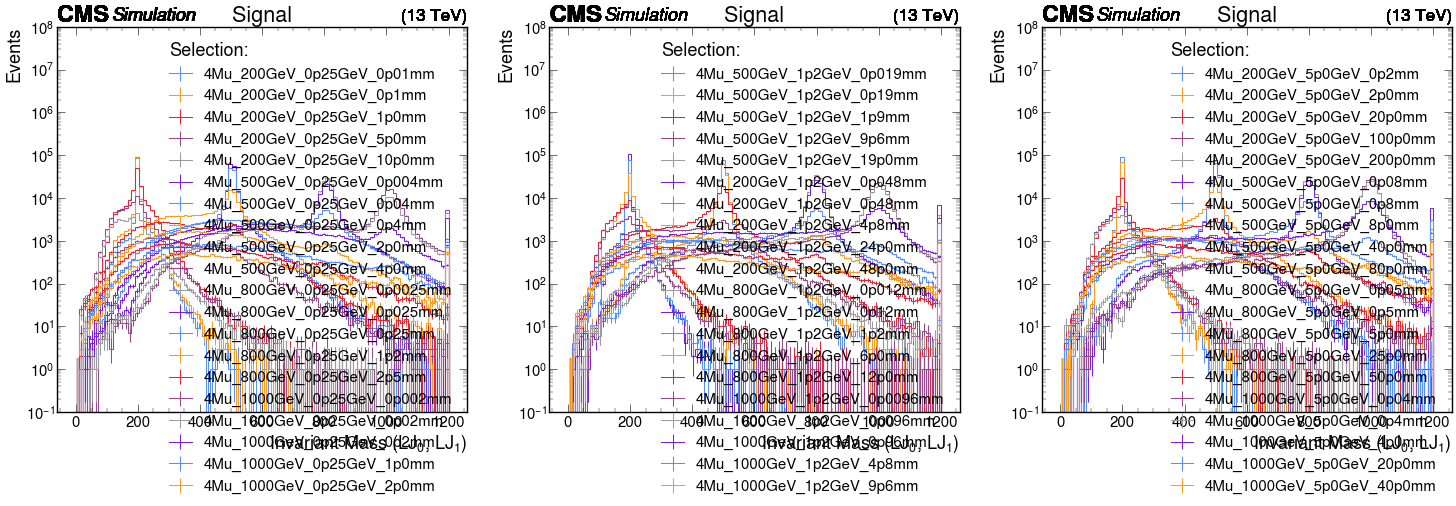

In [13]:
# Plots for signal
plt.subplots(1, 3, figsize=(3*figh, figw))
for sp in (fmulxy1+fmulxy4+fmulxy7+fmulxy0):
    plt.subplot(1,3,1)
    utilities.plot(output[sp]["hists"]["lj_lj_invmass"][ch1, :], label = sp)
    plt.title("Signal")
    plt.ylabel("Events")
    plt.ylim(0.1, 100000000)
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)

for sp in (fmulxy5+fmulxy2+fmulxy8+fmulxyi):
    plt.subplot(1,3,2)
    utilities.plot(output[sp]["hists"]["lj_lj_invmass"][ch1, :], label = sp)
    plt.title("Signal")
    plt.ylabel("Events")
    plt.ylim(0.1, 100000000)
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
    
for sp in (fmulxy3+fmulxy6+fmulxy9+fmulxyx):
    plt.subplot(1,3,3)
    utilities.plot(output[sp]["hists"]["lj_lj_invmass"][ch1, :], label = sp)
    plt.title("Signal")
    plt.ylabel("Events")
    plt.ylim(0.1, 100000000)
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)

## Looking at how each selection affect each signal and background process separately

4Mu 800GeV 1p2GeV 1p2mm


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


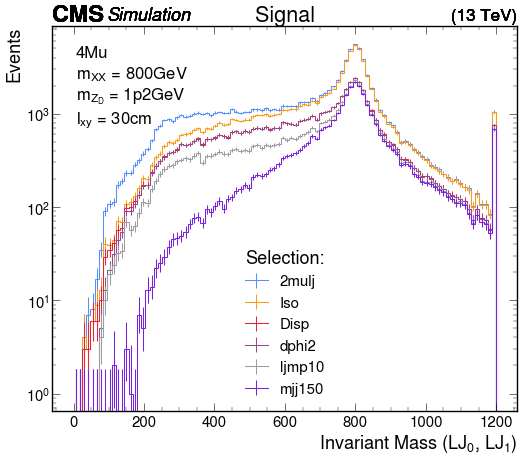

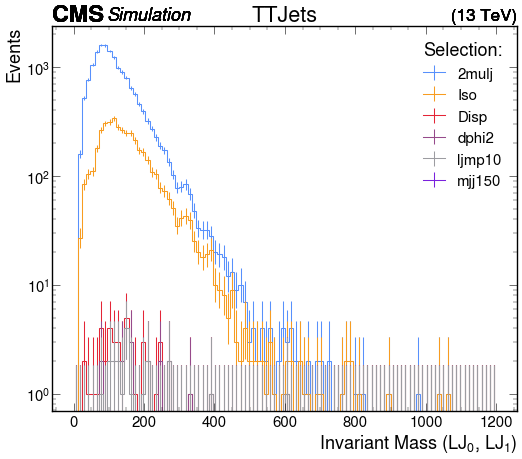

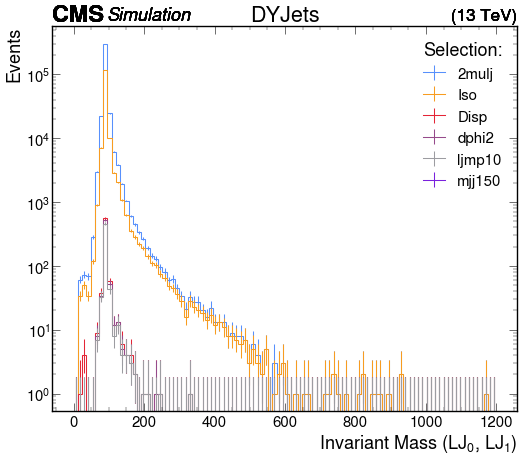

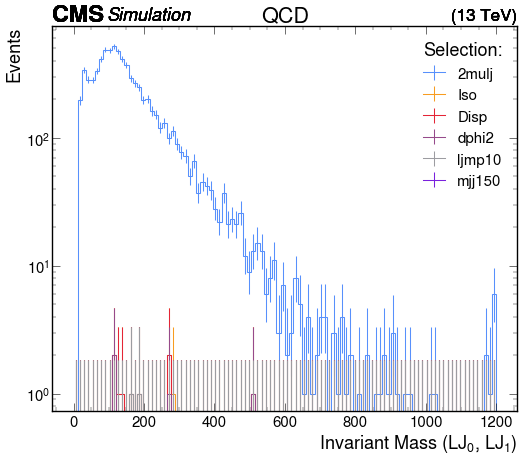

In [14]:
wmu, mxx, mzd, ctau = sss.split("_")
print(wmu, mxx, mzd, ctau)

for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        utilities.plot(output[sss]["hists"][htp][ch, :], label = chaname[ij])
    plt.title("Signal")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
    plt.text(0.05, 0.95,
             f"{wmu}\n"
             f"m$_{{XX}}$ = {mxx} \n"
             f"m$_{{Z_D}}$ = {mzd} \n"
             "$l_{xy}$ = 30cm",
             transform=plt.gca().transAxes,
             fontsize=24,
             va="top"
            )
if (save):plt.savefig(f"clean_plots/fin_bkg_cuts_{vr}_{sisa}_SIG.pdf", bbox_inches="tight", dpi=300)

# TTJets
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        TTJ = merge_bkg(output, bkgttj, htp, ch)
        utilities.plot(TTJ, label = chaname[ij])
    plt.title("TTJets")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
if (save): plt.savefig(f"clean_plots/fin_bkg_cuts_{vr}_{sisa}_TTJ.pdf", bbox_inches="tight", dpi=300)
    
# DYJets
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        DYJ = merge_bkg(output, bkgdyj, htp, ch)
        utilities.plot(DYJ, label = chaname[ij])
    plt.title("DYJets")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
if (save): plt.savefig(f"clean_plots/fin_bkg_cuts_{vr}_{sisa}_DYJ.pdf", bbox_inches="tight", dpi=300)

# QCD
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        QCD = merge_bkg(output, bkgqcd, htp, ch)
        utilities.plot(QCD, label = chaname[ij])
    plt.title("QCD")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
if (save): plt.savefig(f"clean_plots/fin_bkg_cuts_{vr}_{sisa}_QCD.pdf", bbox_inches="tight", dpi=300)

## Stacking Backgrounds for different selections for $m_{xx} = 500$, $m_{z_D} = 0.25$ and changing $l_{xy}$

['bkg_2mulj', 'bkg_2mulj_iso', 'bkg_2mulj_iso_disp', 'bkg_2mulj_iso_disp_dphi', 'bkg_2mulj_iso_disp_dphi_ljmp10', 'bkg_2mulj_iso_disp_dphi_ljmp15', 'bkg_2mulj_iso_disp_dphi_ljmp20', 'bkg_2mulj_iso_disp_dphi_ljmp30', 'bkg_2mulj_iso_disp_dphi_ljmp10_mass150']


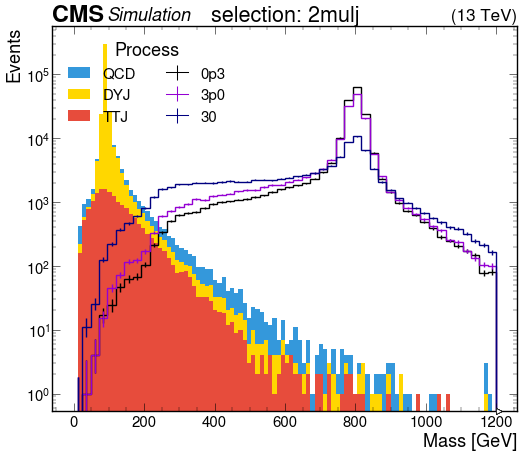

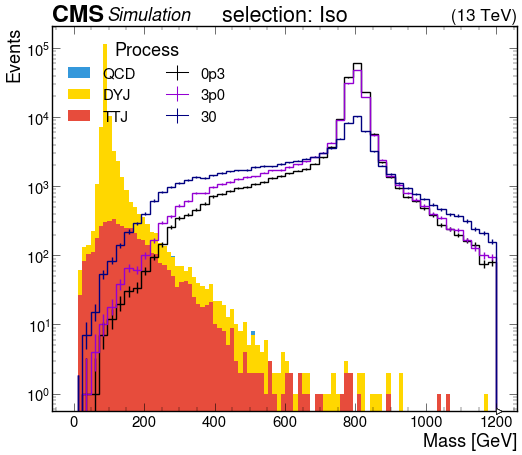

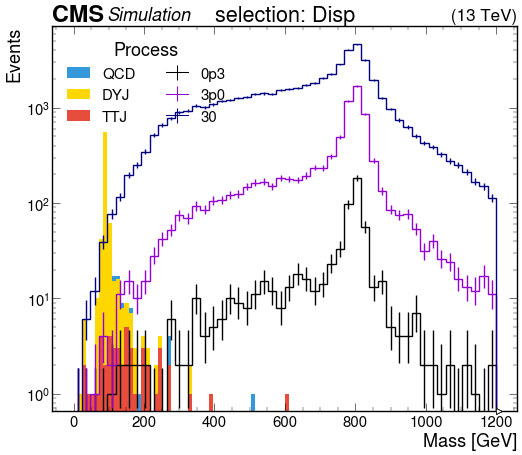

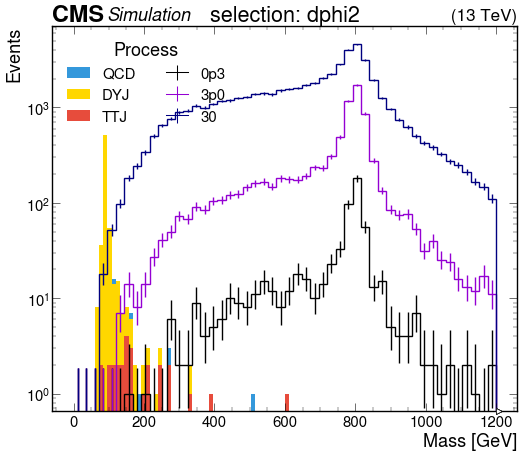

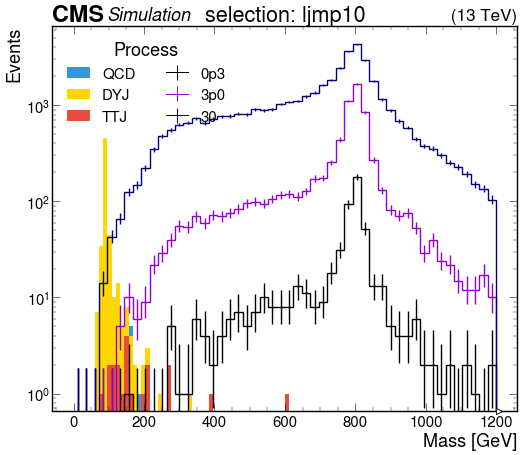

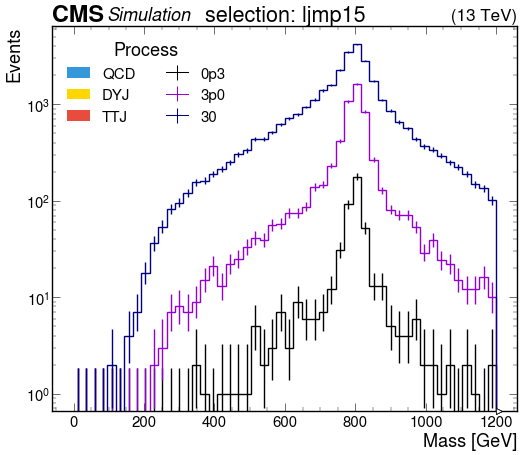

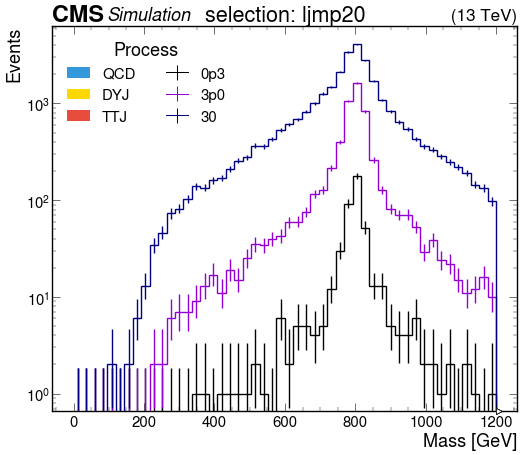

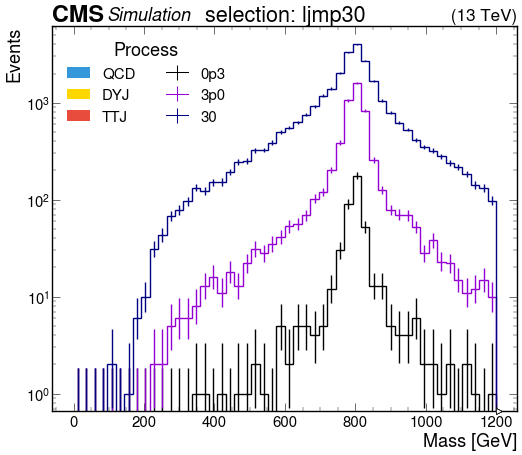

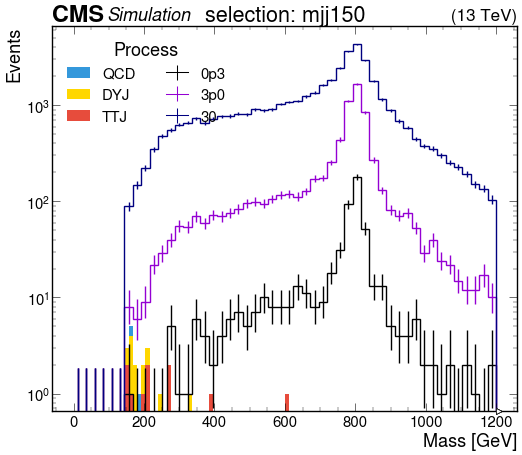

In [28]:
####### Stacking Backgrounds diff selections
for htp in histoplot:
    print(chan)
    for ic, ch in enumerate(chan):
        
        fig, ax = plt.subplots(figsize=(figh, figw))
        
        DYJ = merge_bkg(output, bkgdyj, htp, ch)
        QCD = merge_bkg(output, bkgqcd, htp, ch)
        TTJ = merge_bkg(output, bkgttj, htp, ch)
        
        # Backgrounds
        hep.histplot([TTJ, DYJ, QCD,],
                     stack=True,  histtype="fill", 
                     color=["#E74C3C", "#FFD700", "#3498DB"],
                     label=["TTJ", "DYJ", "QCD"],
                     ax=ax, )
        
        # Signal        
        for ix, sss in enumerate(signal[:3]):
            hep.histplot(output[sss]["hists"][htp][ch, ::2j],  color=colsig[ix], label=labl[ix], histtype="step", linewidth=2, ax=ax)
        hep.cms.label(data=False, lumi=None, com=13, ax=ax)
        # ax.set_ylim(1, 1000000)
        # ax.yscale(1,10000)
        ax.set_xlabel("Mass [GeV]")
        ax.set_ylabel("Events")
        ax.set_yscale("log")
        ax.legend(title="Process", ncol=2)
        plt.title(f"selection: {chaname[ic]}")
        if (save): 
            plt.savefig(f"clean_plots/fin_bkg_stack_{vr}_{sisa}_{htp}_{chaname[ic]}.pdf", bbox_inches="tight", dpi=300)
            # print(f"saving: fin_bkg_stack_{vr}_{sisa}_{htp}_{chaname[ic]}_mxx.pdf")
        # print(f"clean_plots/fin_bkg_stack_{vr}_{htp}_{chaname[ic]}_mxx")

In [38]:
ch = channels[5]
# print(ch)s
for i in fmulxy8:
    print(i)
    output[i]["cutflow"][ch].print_table()
    print()

4Mu_800GeV_1p2GeV_0p012mm
cut name           raw N    weighted N    weighted %
--------------  --------  ------------  ------------
None            195566.0         527.2         100.0
pass triggers   182329.0         491.5          93.2
PV filter       182329.0         491.5          93.2
>=2 LJs         181124.0         488.3          92.6
> 1 mu_lj          644.0           1.7           0.3
LJ-LJ dPhi > 2     631.0           1.7           0.3
ljmass > 0.15      480.0           1.3           0.2

4Mu_800GeV_1p2GeV_0p12mm
cut name           raw N    weighted N    weighted %
--------------  --------  ------------  ------------
None            178213.0         527.2         100.0
pass triggers   166142.0         491.5          93.2
PV filter       166142.0         491.5          93.2
>=2 LJs         164159.0         485.6          92.1
> 1 mu_lj         8246.0          24.4           4.6
LJ-LJ dPhi > 2    8191.0          24.2           4.6
ljmass > 0.15     5958.0          17.6         

In [41]:
## Final yields summary: Signal
# ch = channels[-1]
cuts = ["LJ-LJ dPhi > 2", "ljmass > 0.15"]#, "ljljMass > 150"]#"ljmass > 0.10", "ljmass > 0.15"]#, "ljmass > 0.20", "ljljMass > 150"]
# cuts = ["LJ-LJ dPhi > 2", "ljmass > 0.10","ljljMass > 150"]


In [42]:
for ic, cut in enumerate(cuts):
    print(f"Cut: {cut}")
    # ch = chan[ic+3]
    print(f"{'Sample':<30} {'Yield':>12}")
    print("-" * 44)
    
    # Signal yields
    for sample in all_signal:
        print(f"{sample:<30} {output[sample]['cutflow'][ch].rows[cut]['weighted']:>12.2f}")
        print("-" * 44)

Cut: LJ-LJ dPhi > 2
Sample                                Yield
--------------------------------------------
4Mu_200GeV_0p25GeV_0p01mm              0.01
--------------------------------------------
4Mu_200GeV_0p25GeV_0p1mm               0.12
--------------------------------------------
4Mu_200GeV_0p25GeV_1p0mm               1.04
--------------------------------------------
4Mu_200GeV_0p25GeV_5p0mm               0.77
--------------------------------------------
4Mu_200GeV_0p25GeV_10p0mm              0.57
--------------------------------------------
4Mu_200GeV_1p2GeV_0p048mm              0.00
--------------------------------------------
4Mu_200GeV_1p2GeV_0p48mm               0.09
--------------------------------------------
4Mu_200GeV_1p2GeV_4p8mm                1.00
--------------------------------------------
4Mu_200GeV_1p2GeV_24p0mm               0.75
--------------------------------------------
4Mu_200GeV_1p2GeV_48p0mm               0.56
--------------------------------------------
4

In [43]:
#bkg
for ic, cut in enumerate(cuts):
    print(f"BKG Yields for {cut} \n")
    # Background yields
    dyj = merge_cutflows(output, bkgdyj, ch)
    ttj = merge_cutflows(output, bkgttj, ch)
    qcd = merge_cutflows(output, bkgqcd, ch)
    
    print(f"{'TTJets':<30} {ttj[cut]['weighted']:>12.2f}")
    print("-" * 44)
    print(f"{'DYJ':<30}    {dyj[cut]['weighted']:>12.2f}")
    print("-" * 44)
    print(f"{'QCD':<30}    {qcd[cut]['weighted']:>12.2f}")
    print()

BKG Yields for LJ-LJ dPhi > 2 

TTJets                               407.86
--------------------------------------------
DYJ                                   48158.56
--------------------------------------------
QCD                                    2795.63

BKG Yields for ljmass > 0.15 

TTJets                                 0.00
--------------------------------------------
DYJ                                       0.00
--------------------------------------------
QCD                                       0.00



In [44]:
para aqui

SyntaxError: invalid syntax (3767280655.py, line 1)

## More LJ variables for background and signal for final cut only

## Number of events after every cut's been applied

In [ ]:
ch = chan[-1]
# print(ch)
for i in signal:
    print(i)
    output[i]["cutflow"][ch].print_table()
    print()

In [ ]:
TTJ = merge_cutflows(output, bkgttj, ch)
DYJ = merge_cutflows(output, bkgdyj, ch)
QCD = merge_cutflows(output, bkgqcd, ch)

backgrounds = {
    "TTJ": bkgttj,
    "DYJ": bkgdyj,
    "QCD": bkgqcd,
}

merged_cf = {}

for name, samples in backgrounds.items():
    merged_cf[name] = merge_cutflows(output, samples, ch)

for name, cf in merged_cf.items():
    print(f"\n{name}")
    print(f"{'cut name':<20} {'raw':>12} {'weighted':>15}")
    print("-" * 50)

    for cut, vals in cf.items():
        print(
            f"{cut:<20}"
            f"{vals['raw']:>12,.0f}"
            f"{vals['weighted']:>15,.1f}"
        )

In [ ]:
all_bkgs = bkgdyj + bkgttj + bkgqcd
total_bkg = merge_cutflows(output, all_bkgs, ch)

for cut, vals in total_bkg.items():
    print(
        f"{cut:<20}"
        f"{vals['raw']:>12,.0f}"
        f"{vals['weighted']:>15,.1f}"
    )

In [ ]:
import math
output = coffea.util.load(f"outputs/bkg_32d.coffea")
# for k in output:
#     print(k)
sample = "TTJets"

In [ ]:
ch = "bkg_base_2mulj_iso_disp_dphi_mass175"
cut = "ljljMass > 175"
output["TTJets"]['cutflow'][ch].rows[cut]['weighted']

In [ ]:
print("Available keys:", output[sample]['cutflow'][ch].rows[cut].keys())

In [ ]:
import math

# Get the nominal weighted yield and raw counts from your dictionary
yield_nominal = output[sample]['cutflow'][ch].rows[cut]['weighted']
raw_events = output[sample]['cutflow'][ch].rows[cut]['raw']

if raw_events > 0:
    # 1. Calculate the statistical uncertainty for a weighted sample
    stat_error = yield_nominal / math.sqrt(raw_events)
    
    # 2. Convert to a fractional percentage relative to your nominal yield
    error_fraction = stat_error / yield_nominal  # Simplifies cleanly to 1 / sqrt(raw_events)
    
    # 3. Print the results formatted for Combine
    print(f"--- Statistics for {sample} ---")
    print(f"Weighted Yield: {yield_nominal:.2f}")
    print(f"Raw MC Events : {raw_events}")
    print(f"Stat Error    : ±{stat_error:.2f} ({error_fraction*100:.1f}%)")
    print(f"\nCombine Datacard Entry:")
    print(f"stat_{sample}   lnN   {1.0 + error_fraction:.3f}")
else:
    print(f"Warning: Zero raw events found for {sample}")

In [ ]:
variance_val = output[sample]['cutflow'][ch].rows[cut]['variance']

# 2. Calculate the statistical error (sqrt of variance)
stat_error = math.sqrt(variance_val)

# 3. Print out the error
print(f"Error: {stat_error:>12.2f}")

In [ ]:
output["TTJets"]["cutflow"]["ljljMass > 175"].print_table()

In [ ]:
import math



# 1. Fetch the variance value
variance_val = output[sample]['cutflow'][ch].rows[cut]['variance']

# 2. Calculate the statistical error (sqrt of variance)
stat_error = math.sqrt(variance_val)

# 3. Print out the error
print(f"Error: {stat_error:>12.2f}")